First 5 Rows:
  Machine_Type  Temperature  Vibration   RPM Quality_Status
0            C        79.97      0.710  1213           PASS
1            A        73.62      0.639  2814           FAIL
2            A        81.48      0.509  2181           PASS
3            C        90.23      0.403  1898           FAIL
4            B        72.66      0.605  1709           PASS

Mean Squared Error: 94.85860167868839

Slope (m): -0.00034788289708034326
Intercept (c): 75.91437110975201


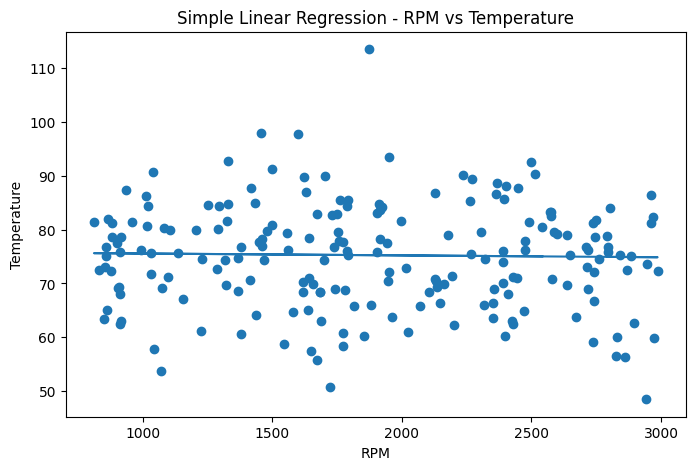

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
df = pd.read_csv("/content/industrial_sensor_dataset.csv")
print("First 5 Rows:")
print(df.head())
X = df[["RPM"]]
y = df["Temperature"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("\nMean Squared Error:", mse)
print("\nSlope (m):", model.coef_[0])
print("Intercept (c):", model.intercept_)
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("RPM")
plt.ylabel("Temperature")
plt.title("Simple Linear Regression - RPM vs Temperature")
plt.show()

First 5 Rows:
  Machine_Type  Temperature  Vibration   RPM Quality_Status
0            C        79.97      0.710  1213           PASS
1            A        73.62      0.639  2814           FAIL
2            A        81.48      0.509  2181           PASS
3            C        90.23      0.403  1898           FAIL
4            B        72.66      0.605  1709           PASS

Mean Squared Error: 95.7160198223557

Intercept:
77.99310777015143

Coefficients:
RPM : -0.0003582537634958172
Vibration : -4.0151677259348375

Actual vs Predicted:
   Actual Temperature  Predicted Temperature
0               80.43              74.725523
1               84.83              76.152190
2               56.59              75.037341
3               69.26              74.426007
4               63.75              74.948655


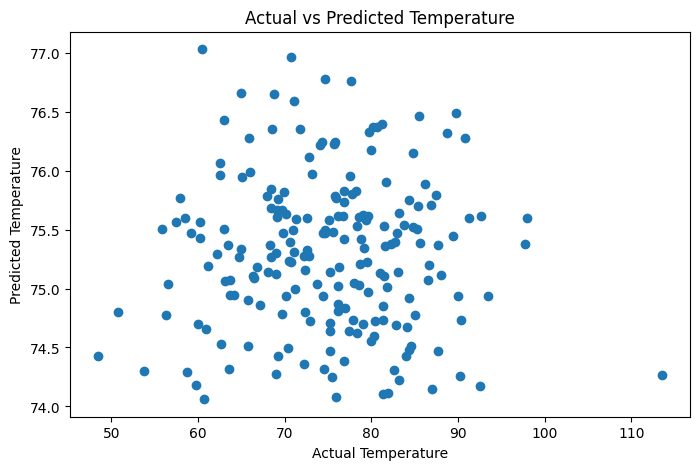

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
df = pd.read_csv("/content/industrial_sensor_dataset.csv")
print("First 5 Rows:")
print(df.head())
X = df[["RPM", "Vibration"]]
y = df["Temperature"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("\nMean Squared Error:", mse)
print("\nIntercept:")
print(model.intercept_)
print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", coef)
comparison = pd.DataFrame({
    "Actual Temperature": y_test.values,
    "Predicted Temperature": y_pred
})
print("\nActual vs Predicted:")
print(comparison.head())
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")
plt.show()

In [4]:
joblib.dump(model, "temperature_prediction_model.pkl")

['temperature_prediction_model.pkl']

In [5]:
import joblib
import pandas as pd
model = joblib.load("/content/temperature_prediction_model.pkl")
new_machine_data = pd.DataFrame({
    "RPM": [2500],
    "Vibration": [0.45]
})
predicted_temperature = model.predict(new_machine_data)
print("\nPredicted Temperature:")
print(predicted_temperature[0])


Predicted Temperature:
75.2906478847412


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
df = pd.read_csv("/content/industrial_sensor_dataset.csv")
print("Dataset Columns:")
print(df.columns)
modes = ["Eco", "Standard", "High-Speed"]
df["Machine_Mode"] = [
    modes[i % 3] for i in range(len(df))
]
print("\nDataset with Machine_Mode:")
print(df.head())
X = df[["RPM", "Vibration", "Machine_Mode"]]
y = df["Temperature"]
categorical_features = ["Machine_Mode"]
numerical_features = ["RPM", "Vibration"]
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("\nMean Squared Error:", mse)
encoder = model.named_steps["preprocessor"]
encoded_columns = encoder.transformers_[0][1].get_feature_names_out(
    categorical_features
)
print("\nEncoded Columns:")
print(encoded_columns)

Dataset Columns:
Index(['Machine_Type', 'Temperature', 'Vibration', 'RPM', 'Quality_Status'], dtype='object')

Dataset with Machine_Mode:
  Machine_Type  Temperature  Vibration   RPM Quality_Status Machine_Mode
0            C        79.97      0.710  1213           PASS          Eco
1            A        73.62      0.639  2814           FAIL     Standard
2            A        81.48      0.509  2181           PASS   High-Speed
3            C        90.23      0.403  1898           FAIL          Eco
4            B        72.66      0.605  1709           PASS     Standard

Mean Squared Error: 94.95593575656213

Encoded Columns:
['Machine_Mode_High-Speed' 'Machine_Mode_Standard']


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
df = pd.read_csv("/content/industrial_sensor_dataset.csv")
print("\nColumns:")
print(df.columns)
modes = ["Eco", "Standard", "High-Speed"]
df["Machine_Mode"] = [
    modes[i % 3] for i in range(len(df))
]
X = df[["RPM", "Vibration", "Machine_Mode"]]
y = df["Temperature"]
categorical_features = ["Machine_Mode"]
numerical_features = ["RPM", "Vibration"]
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("\nTraining Data Size:", len(X_train))
print("Testing Data Size :", len(X_test))
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("\nMean Squared Error:", mse)
comparison = pd.DataFrame({
    "Actual Temperature": y_test.values,
    "Predicted Temperature": y_pred
})
print("\nActual vs Predicted:")
print(comparison.head())


Columns:
Index(['Machine_Type', 'Temperature', 'Vibration', 'RPM', 'Quality_Status'], dtype='object')

Training Data Size: 800
Testing Data Size : 200

Mean Squared Error: 94.95593575656213

Actual vs Predicted:
   Actual Temperature  Predicted Temperature
0               80.43              75.115116
1               84.83              76.599623
2               56.59              75.428221
3               69.26              74.679655
4               63.75              75.217813


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
df = pd.read_csv("/content/industrial_sensor_dataset.csv")
print("\nColumns:")
print(df.columns)
modes = ["Eco", "Standard", "High-Speed"]
df["Machine_Mode"] = [
    modes[i % 3] for i in range(len(df))
]
df["Defective"] = df["Quality_Status"].map({
    "FAIL": 1,
    "PASS": 0
})
X = df[["RPM", "Vibration", "Machine_Mode"]]
y = df["Defective"]
categorical_features = ["Machine_Mode"]
numerical_features = ["RPM", "Vibration"]
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Columns:
Index(['Machine_Type', 'Temperature', 'Vibration', 'RPM', 'Quality_Status'], dtype='object')

Accuracy: 0.855

Confusion Matrix:
[[128  17]
 [ 12  43]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90       145
           1       0.72      0.78      0.75        55

    accuracy                           0.85       200
   macro avg       0.82      0.83      0.82       200
weighted avg       0.86      0.85      0.86       200

